# Prediction Model Training and Testing

## Loading Data Set for training

In [2]:
import pandas as pd

df = pd.read_csv('blackjack_simulator_subset_5m.csv')
df.head()

,shoe_id,cards_remaining,dealer_up,initial_hand,dealer_final,dealer_final_value,player_final,player_final_value,actions_taken,run_count,true_count,win
0,0,416,10,"[10, 11]","[10, 4, 10]",24,"[[10, 11]]",['BJ'],[['S']],1,0,1.5
1,0,411,10,"[5, 5]","[10, 8]",18,"[[5, 5, 11]]",[21],"[['H', 'S']]",-2,0,1.0
2,0,406,6,"[3, 10]","[6, 6, 10]",22,"[[3, 10]]",[13],[['S']],-2,0,1.0
3,0,401,10,"[5, 9]","[10, 8]",18,"[[5, 9, 11, 3]]",[18],"[['H', 'H', 'S']]",-1,0,0.0
4,0,395,8,"[6, 10]","[8, 2, 10]",20,"[[6, 10, 10]]",[26],[['H']],-1,0,-1.0


## Processing and Feature Engineering Data set

In [3]:
import pandas as pd
import ast

df = pd.read_csv("blackjack_simulator_subset_5m.csv")

def is_soft(hand):
    return 1 if 11 in hand and sum(hand) <= 21 else 0

samples = []

for _, row in df.iterrows():
    try:
        hand = ast.literal_eval(row["initial_hand"])
        dealer = int(row["dealer_up"])
        run_count = int(row["run_count"])
        actions = ast.literal_eval(row["actions_taken"])[0]
        result = float(row["win"])

        value = sum(hand)
        soft = is_soft(hand)

        for action in actions:
            samples.append({
                "player_total": value,
                "dealer_card": dealer,
                "soft": soft,
                "running_count": run_count,
                "action": action,
                "result": result
            })
    except Exception as e:
        print(f"Skipping row due to error: {e}")

processed_df = pd.DataFrame(samples)
processed_df.head()


,player_total,dealer_card,soft,running_count,action,result
0,21,10,1,1,S,1.5
1,10,10,0,-2,H,1.0
2,10,10,0,-2,S,1.0
3,13,6,0,-2,S,1.0
4,14,10,0,-1,H,0.0


## Training the Prediction Model

In [4]:
from sklearn.preprocessing import LabelEncoder

le_action = LabelEncoder()
processed_df['action_encoded'] = le_action.fit_transform(processed_df['action'])

# Optional: See mapping
print(dict(zip(le_action.classes_, le_action.transform(le_action.classes_))))
# e.g., {'D': 0, 'H': 1, 'S': 2}

{'D': np.int64(0), 'H': np.int64(1), 'N': np.int64(2), 'P': np.int64(3), 'R': np.int64(4), 'S': np.int64(5)}


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = processed_df[['player_total', 'dealer_card', 'soft', 'running_count']]
y = processed_df['action_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

## Evaluating Model Accuracy

In [6]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_action.classes_))


Accuracy: 0.780646229622557

Classification Report:
              precision    recall  f1-score   support

           D       1.00      0.94      0.97    104278
           H       0.67      0.95      0.79    497673
           N       0.53      0.79      0.64     76778
           P       0.68      0.28      0.39     26193
           R       0.89      0.80      0.84     51970
           S       0.97      0.64      0.77    662263

    accuracy                           0.78   1419155
   macro avg       0.79      0.73      0.73   1419155
weighted avg       0.83      0.78      0.78   1419155



## Visualize Confusion Matrix

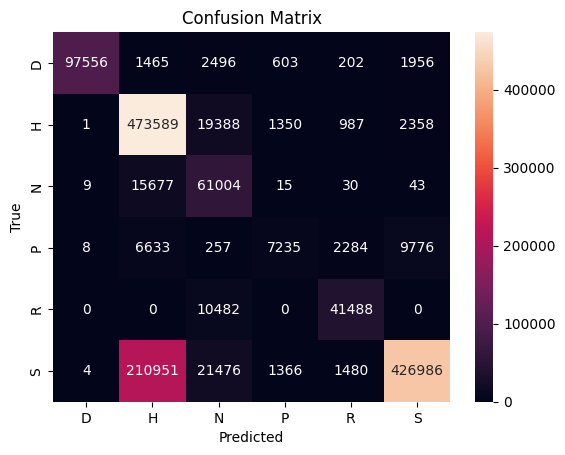

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="d", xticklabels=le_action.classes_, yticklabels=le_action.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Saving the Trained Model
Save the trained model to reuse for prediction by player in Black jack game

In [8]:
import joblib

joblib.dump(model, 'blackjack_action_model.pkl')
joblib.dump(le_action, 'blackjack_label_encoder.pkl')

['blackjack_label_encoder.pkl']

## BlackJack Game Play

In [16]:
import joblib

# Load the trained model and encoder
model = joblib.load("blackjack_action_model.pkl")
label_encoder = joblib.load("blackjack_label_encoder.pkl")

In [17]:
import random
from collections import Counter

SUITS = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
RANKS = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'Jack', 'Queen', 'King', 'Ace']
VALUES = {'2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, 
          'Jack': 10, 'Queen': 10, 'King': 10, 'Ace': 11}


In [18]:
def create_shoe():
    shoe = []
    card_counts = Counter()
    for _ in range(4):  # 4 decks
        for suit in SUITS:
            for rank in RANKS:
                card = (rank, suit)
                shoe.append(card)
                card_counts[card] += 1
    random.shuffle(shoe)
    return shoe, card_counts

def deal_card(shoe, card_counts):
    if not shoe:
        return None, card_counts
    card = shoe.pop()
    card_counts[card] -= 1
    if card_counts[card] == 0:
        del card_counts[card]
    return card, card_counts

def update_running_count(card, running_count):
    if card[0] in ['2', '3', '4', '5', '6']:
        running_count += 1
    elif card[0] in ['10', 'Jack', 'Queen', 'King', 'Ace']:
        running_count -= 1
    return running_count

def calculate_hand_value(hand):
    value = sum(VALUES[card[0]] for card in hand)
    num_aces = sum(1 for card in hand if card[0] == 'Ace')
    while value > 21 and num_aces:
        value -= 10
        num_aces -= 1
    return value

def display_hand(player_name, hand):
    print(f"{player_name}'s hand: ", ', '.join(f'{card[0]} of {card[1]}' for card in hand))
    print(f"Total value: {calculate_hand_value(hand)}")


In [19]:
# def blackjack_strategy(player_hand, dealer_upcard):
#     player_total = sum(VALUES[card[0]] for card in player_hand)
#     if 'Ace' in [card[0] for card in player_hand] and player_total > 21:
#         player_total -= 10
#     if player_total <= 8:
#         return 'hit'  
#     elif player_total == 9:
#         return 'double down' if dealer_upcard in [3, 4, 5, 6] else 'hit'
#     elif player_total == 10:
#         return 'double down' if dealer_upcard in [2, 3, 4, 5, 6, 7] else 'hit'
#     elif player_total == 11:
#         return 'double down'
#     elif player_total == 12:
#         return 'stand' if dealer_upcard in [4, 5, 6] else 'hit'
#     elif 13 <= player_total <= 16:
#         return 'stand' if dealer_upcard in [2, 3, 4, 5, 6] else 'hit'
#     else:
#         return 'stand'

import pandas as pd

def ml_strategy(player_hand, dealer_upcard, running_count, model, label_encoder):
    player_total = calculate_hand_value(player_hand)
    soft = 1 if any(card[0] == 'Ace' for card in player_hand) else 0
    dealer_value = VALUES.get(dealer_upcard[0], 10)

    # Pass a DataFrame with column names
    input_df = pd.DataFrame([{
        'player_total': player_total,
        'dealer_card': dealer_value,
        'soft': soft,
        'running_count': running_count
    }])

    encoded_pred = model.predict(input_df)[0]
    action_code = label_encoder.inverse_transform([encoded_pred])[0]

    action_map = {'H': 'hit', 'S': 'stand', 'D': 'double down'}
    return action_map.get(action_code, 'stand')


def place_bet(bankroll, running_count, base_bet=100):
    if running_count >= 10:
        bet = base_bet * 3
    elif running_count >= 5:
        bet = base_bet * 2
    elif running_count <= -5:
        bet = base_bet * 0.5
    else:
        bet = base_bet
    bet = min(bet, bankroll)
    print(f"Current running count: {running_count}")
    print(f"Your current bankroll is ${bankroll}. Placing a bet of ${bet}.")
    return bet

def check_shoe_size(shoe):
    if len(shoe) <= 15:
        print("Not enough cards left in the shoe to continue the game. Game over!")
        return False
    return True

def check_blackjack(player_hand):
    return calculate_hand_value(player_hand) == 21 and len(player_hand) == 2


In [20]:
# Main game loop
def blackjack_game():
    bankroll = 5000  # Starting bankroll
    min_bet = 50     # Minimum bet
    max_bet = 500    # Maximum bet

    # Initialize shoe (4 decks combined) and card counts
    shoe, card_counts = create_shoe()

    # Track hands played and won
    hands_played = 0
    hands_won = 0
    hands_lost = 0

    # Initialize the running count
    running_count = 0

    while bankroll >= min_bet:
        if not check_shoe_size(shoe):
            break

        # Display running count at the beginning of the hand
        print(f"\nRunning count at the beginning of the hand: {running_count}")
        print(f"Cards left in the shoe: {len(shoe)}")

        # Ask for the player's bet (based on the running count)
        bet = place_bet(bankroll, running_count)

        # Initial hands for player and dealer
        player_hand = []
        dealer_hand = []

        # Deal two cards to each player (player and dealer)
        for _ in range(2):
            card, card_counts = deal_card(shoe, card_counts)
            player_hand.append(card)
            running_count = update_running_count(card, running_count)
            
            card, card_counts = deal_card(shoe, card_counts)
            dealer_hand.append(card)
            running_count = update_running_count(card, running_count)

        # Display initial hands
        display_hand('Player', player_hand)
        print(f"Dealer's hand: {dealer_hand[0][0]} of {dealer_hand[0][1]} and a hidden card")
        print(f"Running count after cards are dealt: {running_count}\n")

        # Check if player has Blackjack
        if check_blackjack(player_hand):
            print("\nPlayer has a Blackjack! Payout 1.5x the bet.")
            bankroll += 1.5 * bet
            print(f"Bankroll after Blackjack win: ${bankroll}")
            hands_played += 1
            hands_won += 1

            # Update the running count at the end of the hand
            for card in player_hand + dealer_hand:
                running_count = update_running_count(card, running_count)

            print(f"Running count after Blackjack hand: {running_count}")
            print(f"Cards left in shoe: {len(shoe)}")  # Display remaining cards in shoe
            continue  # Skip the rest of the round if the player has Blackjack

        # Player's turn
        player_value = calculate_hand_value(player_hand)
        dealer_upcard_value = VALUES[dealer_hand[0][0]]

        # Set the flag for whether double down is allowed after the initial deal
        double_down_allowed = True

        while player_value < 21:
            # action = blackjack_strategy(player_hand, dealer_upcard_value)  # Pass full player hand
            action = ml_strategy(player_hand, dealer_hand[0], running_count, model, label_encoder)

            print(f"Player's strategy suggests to: {action}")

            if action == 'hit':
                if len(shoe) == 0:  # Ensure there are cards to pop from the shoe
                    print("No cards left in the shoe! Ending the game.")
                    return
                new_card, card_counts = deal_card(shoe, card_counts)
                player_hand.append(new_card)
                running_count = update_running_count(new_card, running_count)  # Update running count
                display_hand('Player', player_hand)
            elif action == 'stand':
                break
            elif action == 'double down' and double_down_allowed:
                if bankroll >= bet * 2:  # Check if player has enough bankroll to double down
                    if len(shoe) == 0:  # Ensure there are cards to pop from the shoe
                        print("No cards left in the shoe! Ending the game.")
                        return
                    new_card, card_counts = deal_card(shoe, card_counts)
                    player_hand.append(new_card)
                    running_count = update_running_count(new_card, running_count)  # Update running count
                    bet *= 2  # Double the bet
                    player_value = calculate_hand_value(player_hand)  # Recalculate after doubling down
                    display_hand('Player', player_hand)
                    print("Player doubled down!")
                    double_down_allowed = False  # Disable further double down during this round
                    break
                else:
                    print("Not enough funds to double down. Proceeding with hit or stand.")
                    continue
            player_value = calculate_hand_value(player_hand)

        # Check if player busted
        if player_value > 21:
            print("\nPlayer busts! Dealer wins.")
            bankroll -= bet
            hands_played += 1
            hands_lost += 1
            print(f"Bankroll after loss: ${bankroll}")

            # Update the running count at the end of the hand
            for card in player_hand + dealer_hand:
                running_count = update_running_count(card, running_count)

            print(f"Running count after bust: {running_count}")
            print(f"Cards left in shoe: {len(shoe)}")  # Display remaining cards in shoe
            continue

        # Dealer's turn
        print("\nDealer's turn...")
        display_hand('Dealer', dealer_hand)
        while calculate_hand_value(dealer_hand) < 17:
            print("Dealer hits!")
            if len(shoe) == 0:  # Ensure there are cards to pop from the shoe
                print("No cards left in the shoe! Ending the game.")
                return
            new_card, card_counts = deal_card(shoe, card_counts)
            dealer_hand.append(new_card)
            running_count = update_running_count(new_card, running_count)  # Update running count
            display_hand('Dealer', dealer_hand)

        # Check if dealer busted
        dealer_value = calculate_hand_value(dealer_hand)
        if dealer_value > 21:
            print("\nDealer busts! Player wins.")
            bankroll += bet
            hands_played += 1
            hands_won += 1
            print(f"Bankroll after win: ${bankroll}")

        # Compare player and dealer values if neither busts
        elif player_value > dealer_value:
            print("\nPlayer wins!")
            bankroll += bet
            hands_played += 1
            hands_won += 1
            print(f"Bankroll after win: ${bankroll}")
        elif player_value < dealer_value:
            print("\nDealer wins!")
            bankroll -= bet
            hands_played += 1
            hands_lost += 1
            print(f"Bankroll after loss: ${bankroll}")
        else:
            print("\nIt's a tie!")

        # Update the running count at the end of the hand
        for card in player_hand + dealer_hand:
            running_count = update_running_count(card, running_count)

        print(f"Running count after hand: {running_count}")
        print(f"Cards left in shoe: {len(shoe)}\n")

    # Print stats at the end of the game
    print("Game over.")
    print(f"Total hands played: {hands_played}")
    print(f"Hands won: {hands_won}")
    print(f"Hands lost: {hands_lost}")

In [21]:
blackjack_game()



Running count at the beginning of the hand: 0
Cards left in the shoe: 208
Current running count: 0
Your current bankroll is $5000. Placing a bet of $100.
Player's hand:  King of Spades, 8 of Clubs
Total value: 18
Dealer's hand: King of Spades and a hidden card
Running count after cards are dealt: -3

Player's strategy suggests to: stand

Dealer's turn...
Dealer's hand:  King of Spades, 10 of Diamonds
Total value: 20

Dealer wins!
Bankroll after loss: $4900
Running count after hand: -6
Cards left in shoe: 204


Running count at the beginning of the hand: -6
Cards left in the shoe: 204
Current running count: -6
Your current bankroll is $4900. Placing a bet of $50.0.
Player's hand:  Queen of Hearts, 8 of Hearts
Total value: 18
Dealer's hand: 5 of Hearts and a hidden card
Running count after cards are dealt: -7

Player's strategy suggests to: stand

Dealer's turn...
Dealer's hand:  5 of Hearts, 10 of Spades
Total value: 15
Dealer hits!
Dealer's hand:  5 of Hearts, 10 of Spades, 5 of Heart